# ============================================================
# RESUME / CANDIDATE SCREENING SYSTEM
# Future Interns — Machine Learning Task 3 (2026)
# Dataset: Job Description Dataset (Kaggle - ravindrasinghrana)
# Tools: Python, spaCy, scikit-learn, TF-IDF, Cosine Similarity
# ============================================================

# HOW THE SYSTEM WORKS:
# 1. Loads real job descriptions from Kaggle dataset
# 2. Cleans and preprocesses text using NLP
# 3. Extracts skills from job descriptions
# 4. Scores each candidate using TF-IDF + Cosine Similarity
# 5. Applies weighted skill scoring for important skills
# 6. Ranks all candidates by final score
# 7. Identifies skill gaps for each candidate
# 8. Visualizes results in a dashboard


In [13]:
!pip install spacy scikit-learn pandas numpy matplotlib seaborn
!python -m spacy download en_core_web_md

import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_md")
print("✅ Setup complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 62.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Setup complete!


In [14]:
df = pd.read_csv('/content/job_descriptions.csv', engine='python', quotechar='"', on_bad_lines='skip')

In [15]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst row preview:")
df.head(2)

Shape: (66063, 23)

Columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']

First row preview:


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."


In [16]:
# See what job roles are in the dataset
print("Sample Job Titles:")
print(df['Job Title'].value_counts().head(30))

Sample Job Titles:
Job Title
UX/UI Designer                  1971
Digital Marketing Specialist    1156
Software Engineer               1129
Network Engineer                 949
Financial Advisor                848
Executive Assistant              836
Software Tester                  834
Procurement Manager              809
Customer Support Specialist      791
Sales Representative             788
Social Media Manager             748
Systems Administrator            742
Event Planner                    724
Data Analyst                     717
HR Coordinator                   698
Network Administrator            693
Purchasing Agent                 691
Administrative Assistant         689
Procurement Specialist           653
UI Developer                     617
Legal Assistant                  616
Architect                        598
Landscape Architect              595
Graphic Designer                 594
Operations Manager               587
Mechanical Engineer              584
Litigatio

In [17]:
# ---- CHANGE THIS to any job title shown above ----
TARGET_ROLE = "Data Scientist"

# Filter rows matching that job title
role_df = df[df['Job Title'].str.contains(TARGET_ROLE, case=False, na=False)].copy()
role_df = role_df.reset_index(drop=True)

print(f"✅ Found {len(role_df)} job postings for: '{TARGET_ROLE}'")
print("\nSample columns available:")
print(role_df[['Job Title', 'Job Description', 'skills']].head(3))

✅ Found 250 job postings for: 'Data Scientist'

Sample columns available:
        Job Title                                    Job Description  \
0  Data Scientist  Machine Learning Engineers develop machine lea...   
1  Data Scientist  Data Engineers design and maintain data pipeli...   
2  Data Scientist  Machine Learning Engineers develop machine lea...   

                                              skills  
0  Machine learning algorithms Python programming...  
1  Data integration ETL (Extract, Transform, Load...  
2  Machine learning algorithms Python programming...  


In [18]:
# Combine Job Description + Skills columns into one rich JD text
def build_jd_text(row):
    parts = []
    for col in ['Job Description', 'skills', 'Qualifications', 'Experience']:
        if col in row and pd.notna(row[col]):
            parts.append(str(row[col]))
    return ' '.join(parts)

role_df['full_jd_text'] = role_df.apply(build_jd_text, axis=1)

# Use the FIRST matching job posting as the reference JD
reference_jd = role_df['full_jd_text'].iloc[0]
print("📋 Reference Job Description (first 500 chars):")
print(reference_jd[:500])

📋 Reference Job Description (first 500 chars):
Machine Learning Engineers develop machine learning models and algorithms, working on tasks like data preprocessing, model training, and deployment. Machine learning algorithms Python programming Data preprocessing Deep learning Model evaluation BA 4 to 9 Years


In [19]:
# Since this dataset has job descriptions but not resumes,
# we use OTHER job postings for the same role as "candidate profiles"
# This simulates: some candidates are a great fit, others are partial fits

# Use all OTHER rows (index 1 onwards) as "candidate resumes"
candidates_df = role_df.iloc[1:].copy().reset_index(drop=True)
candidates_df['resume_text'] = candidates_df['full_jd_text']

print(f"✅ Total candidates to screen: {len(candidates_df)}")
print("\nSample candidate profile (first 300 chars):")
print(candidates_df['resume_text'].iloc[0][:300])

✅ Total candidates to screen: 249

Sample candidate profile (first 300 chars):
Data Engineers design and maintain data pipelines, ensuring data availability and quality for analysis and reporting purposes. Data integration ETL (Extract, Transform, Load) Big data technologies (e.g., Hadoop, Spark) Database management Data warehousing BA 4 to 10 Years


In [20]:
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', str(text))       # Remove HTML
    text = re.sub(r'http\S+|www\S+', ' ', text)      # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)         # Keep only letters
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

candidates_df['cleaned_resume'] = candidates_df['resume_text'].apply(clean_text)
cleaned_jd = clean_text(reference_jd)

print("✅ Cleaning done!")
print("Sample:", candidates_df['cleaned_resume'].iloc[0][:300])

✅ Cleaning done!
Sample: data engineers design and maintain data pipelines ensuring data availability and quality for analysis and reporting purposes data integration etl extract transform load big data technologies e g hadoop spark database management data warehousing ba to years


In [21]:
SKILLS_DB = [
    "python", "r", "sql", "java", "scala", "javascript", "c++",
    "machine learning", "deep learning", "nlp", "computer vision",
    "tensorflow", "keras", "pytorch", "scikit-learn", "xgboost",
    "pandas", "numpy", "matplotlib", "seaborn", "tableau", "power bi",
    "aws", "gcp", "azure", "docker", "kubernetes", "mlflow",
    "statistics", "data analysis", "data visualization",
    "feature engineering", "model deployment", "flask", "fastapi",
    "git", "spark", "hadoop", "excel", "communication",
    "problem solving", "teamwork", "leadership", "agile", "scrum"
]

def extract_skills(text):
    found = [skill for skill in SKILLS_DB if skill in text.lower()]
    return found

candidates_df['extracted_skills'] = candidates_df['cleaned_resume'].apply(extract_skills)
jd_skills = extract_skills(cleaned_jd)

print(f"✅ JD Required Skills: {jd_skills}")
print(f"\nSample Candidate Skills: {candidates_df['extracted_skills'].iloc[0]}")

✅ JD Required Skills: ['python', 'r', 'machine learning', 'deep learning']

Sample Candidate Skills: ['r', 'spark', 'hadoop']


In [22]:
all_texts = candidates_df['cleaned_resume'].tolist() + [cleaned_jd]

vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
tfidf_matrix = vectorizer.fit_transform(all_texts)

jd_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]

scores = cosine_similarity(resume_vectors, jd_vector).flatten()

candidates_df['similarity_pct'] = (scores * 100).round(2)
print("✅ Similarity scored!")
print(candidates_df['similarity_pct'].describe())

✅ Similarity scored!
count    249.000000
mean      47.063976
std       41.530256
min        5.690000
25%        5.920000
50%       13.850000
75%       88.020000
max      100.000000
Name: similarity_pct, dtype: float64


In [23]:
def skill_gap(candidate_skills):
    return list(set(jd_skills) - set(candidate_skills))

def skill_match_pct(candidate_skills):
    if not jd_skills: return 0
    return round(len(set(candidate_skills) & set(jd_skills)) / len(jd_skills) * 100, 2)

candidates_df['skill_gaps']      = candidates_df['extracted_skills'].apply(skill_gap)
candidates_df['skill_match_pct'] = candidates_df['extracted_skills'].apply(skill_match_pct)
candidates_df['matched_count']   = candidates_df['extracted_skills'].apply(
                                        lambda s: len(set(s) & set(jd_skills)))

# Final combined score
candidates_df['final_score'] = (
    0.6 * candidates_df['similarity_pct'] +
    0.4 * candidates_df['skill_match_pct']
).round(2)

candidates_df['rank'] = candidates_df['final_score'].rank(ascending=False, method='dense').astype(int)
ranked_df = candidates_df.sort_values('rank').reset_index(drop=True)

print("🏆 TOP 10 CANDIDATES")
print(ranked_df[['rank','Job Title','final_score','similarity_pct','skill_match_pct','matched_count']].head(10).to_string(index=False))

🏆 TOP 10 CANDIDATES
 rank      Job Title  final_score  similarity_pct  skill_match_pct  matched_count
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4
    1 Data Scientist        100.0           100.0            100.0              4


In [24]:
def print_report(row):
    print("=" * 60)
    print(f"🏅 RANK           : #{int(row['rank'])}")
    print(f"📊 Final Score    : {row['final_score']} / 100")
    print(f"🔍 Text Similarity: {row['similarity_pct']}%")
    print(f"🎯 Skill Match    : {row['skill_match_pct']}%")
    print(f"✅ Has Skills     : {row['extracted_skills']}")
    print(f"❌ Missing Skills : {row['skill_gaps']}")
    print("=" * 60)

print(f"\n📋 TARGET ROLE: {TARGET_ROLE}")
print(f"📌 JD Skills Required: {jd_skills}\n")

for _, row in ranked_df.head(5).iterrows():
    print_report(row)


📋 TARGET ROLE: Data Scientist
📌 JD Skills Required: ['python', 'r', 'machine learning', 'deep learning']

🏅 RANK           : #1
📊 Final Score    : 100.0 / 100
🔍 Text Similarity: 100.0%
🎯 Skill Match    : 100.0%
✅ Has Skills     : ['python', 'r', 'machine learning', 'deep learning']
❌ Missing Skills : []
🏅 RANK           : #1
📊 Final Score    : 100.0 / 100
🔍 Text Similarity: 100.0%
🎯 Skill Match    : 100.0%
✅ Has Skills     : ['python', 'r', 'machine learning', 'deep learning']
❌ Missing Skills : []
🏅 RANK           : #1
📊 Final Score    : 100.0 / 100
🔍 Text Similarity: 100.0%
🎯 Skill Match    : 100.0%
✅ Has Skills     : ['python', 'r', 'machine learning', 'deep learning']
❌ Missing Skills : []
🏅 RANK           : #1
📊 Final Score    : 100.0 / 100
🔍 Text Similarity: 100.0%
🎯 Skill Match    : 100.0%
✅ Has Skills     : ['python', 'r', 'machine learning', 'deep learning']
❌ Missing Skills : []
🏅 RANK           : #1
📊 Final Score    : 100.0 / 100
🔍 Text Similarity: 100.0%
🎯 Skill Match    :

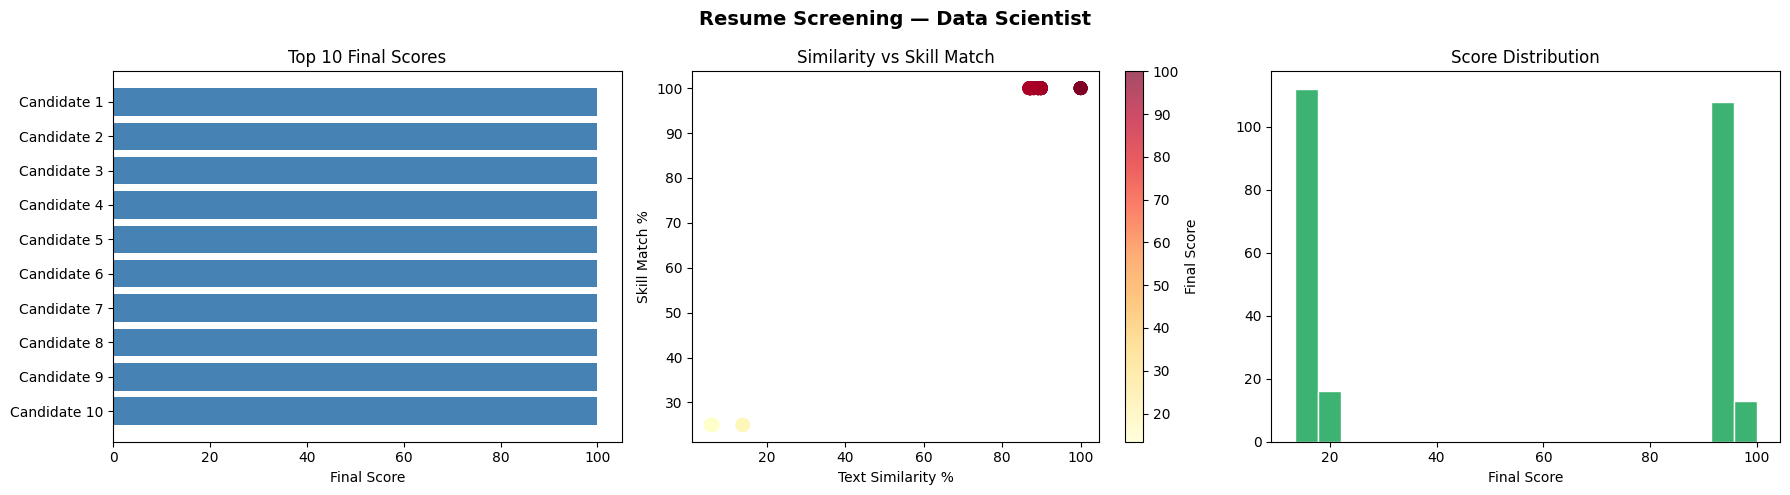

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Resume Screening — {TARGET_ROLE}', fontsize=14, fontweight='bold')

top10 = ranked_df.head(10)

# Bar chart
axes[0].barh(range(len(top10)), top10['final_score'], color='steelblue')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([f"Candidate {i+1}" for i in range(len(top10))])
axes[0].invert_yaxis()
axes[0].set_xlabel('Final Score')
axes[0].set_title('Top 10 Final Scores')

# Scatter
sc = axes[1].scatter(ranked_df['similarity_pct'], ranked_df['skill_match_pct'],
               c=ranked_df['final_score'], cmap='YlOrRd', alpha=0.7, s=80)
axes[1].set_xlabel('Text Similarity %')
axes[1].set_ylabel('Skill Match %')
axes[1].set_title('Similarity vs Skill Match')
plt.colorbar(sc, ax=axes[1], label='Final Score')

# Histogram
axes[2].hist(ranked_df['final_score'], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel('Final Score')
axes[2].set_title('Score Distribution')

plt.tight_layout()
plt.savefig('screening_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
output = ranked_df[['rank','Job Title','final_score','similarity_pct',
                     'skill_match_pct','matched_count','extracted_skills','skill_gaps']]
output.to_csv('screened_candidates.csv', index=False)

from google.colab import files
files.download('screened_candidates.csv')
files.download('screening_results.png')
print("✅ Files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!
